# HIPÓTESIS 3: "La demanda de alojamientos en Málaga presenta un pico de crecimiento superior al 50% durante el tercer trimestre del año (Q3), siendo el Distrito Centro el que mantiene una demanda más estable frente a las otras zonas."

*Contexto de negocio: El turismo en ciudades costeras como Málaga suele sufrir de alta estacionalidad debido al turismo de sol y playa en verano (julio, agosto y septiembre). El objetivo de este análisis es verificar si la demanda (medida a través del volumen de reseñas mensuales) realmente se dispara más de un 50% en el tercer trimestre y si el Distrito Centro, por su oferta cultural y comercial, actúa como un motor desestacionalizado y estable todo el año frente a los distritos periféricos.*

## Preparación

In [4]:
# Preparación, filtros y unión de datos:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset limpio e histórico de reviews
df_2025 = pd.read_csv("../src/data/df_2025.csv") # Archivo limpio. SIN ID DE LA CASA.
listings = pd.read_csv("../src/data/listings.csv") # El istado de todas las casas de Airbnb en Málaga, tiene número de la casa (id), nombre, precio y BARRIO (neighbourhood)
reviews = pd.read_csv("../src/data/reviews.csv") # Historial de actividad: solo tiene 2 datos, la fecha y el número de la casa (id)

Para poder juntar las opiniones (reviews.csv) con la tabla limpia de alojamientos (df_2025.csv), necesitamos una columna común. Esa columna común debería ser el número de identificación de la casa (id).

Como en df_2025.csv esa columna se borró en la limpieza, vamos a cruzar el df_2025 con el listings original usando tres campos que no cambian: el nombre del alojamiento (name), el número del dueño (host_id) y el precio (price). Así, buscaremos la casa exacta y nos devolverá su número de id.

In [7]:
# RECUPERAR LOS IDS Y PREPARAR EL DATASET LIMPIO

# Quitamos duplicados del archivo origina
listings_unicos = listings.drop_duplicates(subset=['name', 'host_id', 'price'])[['id', 'name', 'host_id', 'price']]

# Hacemos el merge. Juntamos df_2025 con los IDs recuperados
df_2025_con_id = pd.merge(df_2025, listings_unicos, on=['name', 'host_id', 'price'], how='inner')

# Cambiamos el nombre a la columna 'id' para que se llame 'listing_id'
# Para que se llame EXACTAMENTE IGUAL que en el archivo de reviews
df_2025_con_id = df_2025_con_id.rename(columns={'id': 'listing_id'})

# Comprobamos que no hayamos perdido ninguna fila de tu trabajo previo
print(f"Filas originales en df_2025: {len(df_2025)}")
print(f"Filas tras recuperar el ID: {len(df_2025_con_id)}")

Filas originales en df_2025: 6861
Filas tras recuperar el ID: 6861


In [8]:
# LIMPIEZA Y EXTRACCIÓN DE LOS TIEMPOS DE LAS RESEÑAS

# Pasamos el tipo de fecha a datetime
reviews['date'] = pd.to_datetime(reviews['date'])

# Vamos a quedarmos solo con las opiniones de 2024 y de 2025
reviews_recientes = reviews[reviews['date'].dt.year.isin([2024, 2025])].copy()

# Extraemos el número de mes
reviews_recientes['mes'] = reviews_recientes['date'].dt.month

# Extraemos el trimestre (Q1 hasta Q4)
reviews_recientes['trimestre'] = 'Q' + reviews_recientes['date'].dt.quarter.astype(str)

# Imprimimos cuántas opiniones nos quedan tras filtrar
print(f"Total de opiniones en el archivo original: {len(reviews)}")
print(f"Opiniones del periodo reciente (2024-2025): {len(reviews_recientes)}")

Total de opiniones en el archivo original: 487221
Opiniones del periodo reciente (2024-2025): 207883


In [9]:
# MERGE DE REVIEWS CON LOS BARRIOS DEL  DATASET LIMPIO

# Usamos 'listing_id' como eslabón común
df_estacionalidad = pd.merge(
    reviews_recientes, 
    df_2025_con_id[['listing_id', 'neighbourhood']], 
    on='listing_id', 
    how='inner'
)

# Comprobamos cuántas opiniones nos quedan en total como alojamientos válidos
print(f"Total de reseñas listas para el análisis de estacionalidad: {len(df_estacionalidad)}")

Total de reseñas listas para el análisis de estacionalidad: 197476


## Análisis Bivariante: Marco global de Málaga  
Vamos a empezar a responder a la primera parte de la hipótesis: ¿Realmente la demanda sube más de un 50% en verano (Q3) comparado con la primavera (Q2)?

- Vamos a contar cuántas de ese montón de reseñas ocurrieron en cada trimestre (Q1, Q2, Q3, Q4).

- Vamos a sacar la fórmula matemática del porcentaje para ver cuánto sube (o baja) el verano respecto a la primavera.

- Vamos a pintar un gráfico de barras para ver de un vistazo qué meses son los reyes del turismo en Málaga.

--- Cantidad de opiniones por Trimestre ---
trimestre
Q1    44576
Q2    64398
Q3    63972
Q4    24530
Name: count, dtype: int64

Variación real de la demanda en Verano (Q3) frente a Primavera (Q2): -0.66%


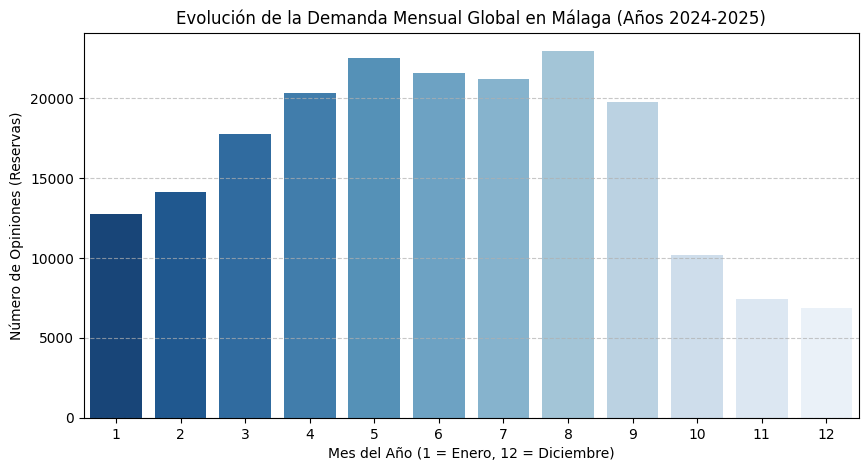

In [10]:
# 1. Contamos cuántas opiniones hay en cada Q y las ordenamos
demand_por_trimestre = df_estacionalidad['trimestre'].value_counts().sort_index()

print("--- Cantidad de opiniones por Trimestre ---")
print(demand_por_trimestre)

# Luego calculamos el cambio porcentual de Q3 frente a Q2
q2_opiniones = demand_por_trimestre['Q2']
q3_opiniones = demand_por_trimestre['Q3']

# Fórmula: ((Final - Inicial) / Inicial) * 100
variacion_verano = ((q3_opiniones - q2_opiniones) / q2_opiniones) * 100

print(f"\nVariación real de la demanda en Verano (Q3) frente a Primavera (Q2): {variacion_verano:.2f}%")

# GRÁFICO: Pintamos la evolución mes a mes
plt.figure(figsize=(10, 5))
# Dibujamos las barras usando el número de mes
sns.countplot(data=df_estacionalidad, x='mes', palette='Blues_r')

# Ponemos los títulos del gráfico
plt.title('Evolución de la Demanda Mensual Global en Málaga (Años 2024-2025)')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Número de Opiniones (Reservas)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Una rejilla flojita de fondo para leer mejor
plt.show()

## Análisis Multivariante (¿Ocurre lo mismo en todos los barrios?) 
Ya conocemos lo que pasa en toda Málaga, el marco global. Ahora vamos a ver la segunda parte de la hipótesis: ¿Es el Distrito Centro el más estable todo el año? ¿Qué pasa en los demás barrios?

Para responder a esto sin que los barrios grandes (como el Centro) aplasten a los pequeños (como Teatinos), vamos a usar la normalización. En lugar de contar "número de reseñas", calculamos qué porcentaje de sus propios clientes recibe cada barrio en cada trimestre.

--- Tasa de crecimiento/decrecimiento en Verano por Barrio ---
neighbourhood
Teatinos-Universidad    124.47
Puerto de la Torre       23.00
Ciudad Jardin            18.88
Cruz De Humilladero      14.97
Palma-Palmilla            9.72
Churriana                 9.34
Este                      8.91
Campanillas               5.21
Bailen-Miraflores         0.33
Carretera de Cadiz        0.16
Centro                   -3.88
Name: Crecimiento_Verano_%, dtype: float64

--- Distribución del 100% de la demanda de cada barrio entre los 4 trimestres ---
trimestre                Q1     Q2     Q3     Q4
neighbourhood                                   
Bailen-Miraflores     19.75  34.49  34.61  11.15
Campanillas           19.16  33.45  35.19  12.20
Carretera de Cadiz    21.63  32.92  32.98  12.47
Centro                23.64  32.42  31.16  12.78
Churriana             16.97  34.08  37.27  11.69
Ciudad Jardin         17.97  33.08  39.32   9.62
Cruz De Humilladero   19.97  31.37  36.06  12.61
Este           

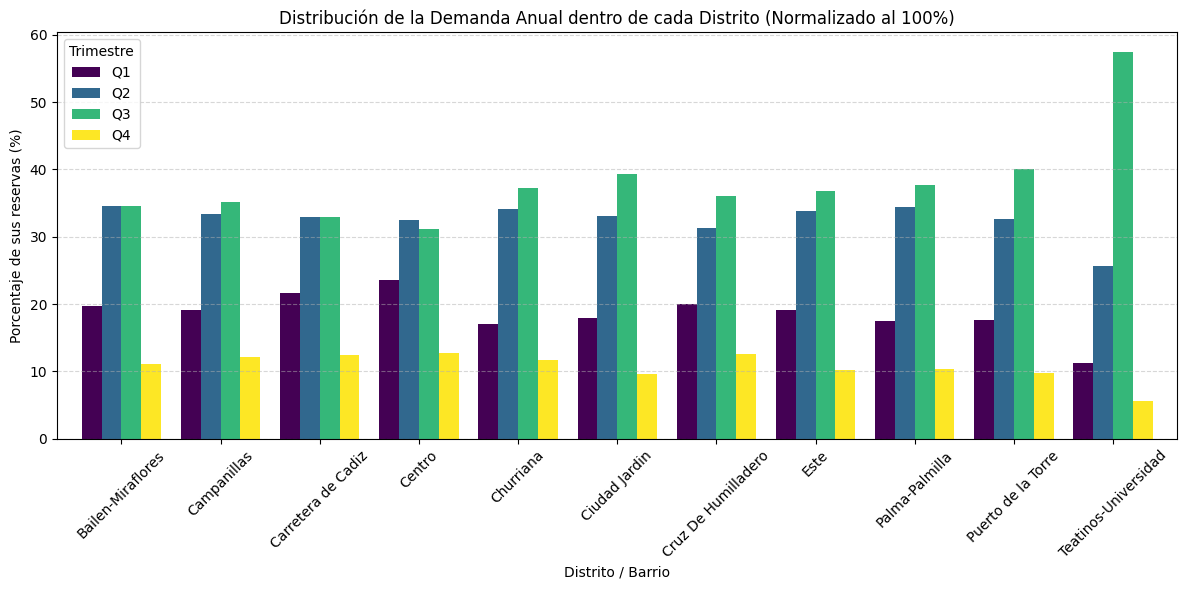

In [11]:
# Compararemos barrios por trimestre
# Primero creamos una tabla cruzada: cuenta cuántas reseñas tiene cada barrio en cada trimestre
tabla_absoluta = pd.crosstab(df_estacionalidad['neighbourhood'], df_estacionalidad['trimestre'])

# Calculamos, ¿Cuánto crece o baja cada uno en verano (Q3 vs Q2)?, por barrio
tabla_absoluta['Crecimiento_Verano_%'] = ((tabla_absoluta['Q3'] - tabla_absoluta['Q2']) / tabla_absoluta['Q2']) * 100

print("--- Tasa de crecimiento/decrecimiento en Verano por Barrio ---")
print(tabla_absoluta['Crecimiento_Verano_%'].sort_values(ascending=False).round(2))

# Normaliz. Para calcular el reparto porcentual interno de cada barrio (debe sumar 100%)
# Para comparar la forma de la estacionalidad de cada barrio justamente
tabla_porcentual = tabla_absoluta[['Q1', 'Q2', 'Q3', 'Q4']].div(tabla_absoluta[['Q1', 'Q2', 'Q3', 'Q4']].sum(axis=1), axis=0) * 100

print("\n--- Distribución del 100% de la demanda de cada barrio entre los 4 trimestres ---")
print(tabla_porcentual.round(2))

# Pintamos en el gráfico las barras agrupadas
tabla_porcentual.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis')

plt.title('Distribución de la Demanda Anual dentro de cada Distrito (Normalizado al 100%)')
plt.xlabel('Distrito / Barrio')
plt.ylabel('Porcentaje de sus reservas (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Trimestre')
plt.xticks(rotation=45) # Giramos los nombres de los barrios para que se lean bien
plt.tight_layout()
plt.show()

## Conclusión Final de la Hipótesis 3

Tras conectar las opiniones recientes (2024-2025) con los barrios de nuestro dataset limpio, podemos concluir que la hipótesis **se rechaza en su primera parte y se acepta en la segunda**:

1. **Rechazo del crecimiento del 50% en verano (Global):** La demanda global de Málaga no sube un 50% en verano (Q3) frente a la primavera (Q2). De hecho, experimenta una ligerísima bajada del **-0.66%**. Esto demuestra que Málaga ya no es un destino puramente veraniego, sino que ha logrado estabilizar su turismo atrayendo el mismo volumen de personas en primavera que en verano.
2. **Validación de la estabilidad del Centro:** El Distrito Centro se confirma como la zona más madura y estable de la ciudad. Su variación en verano es de apenas el **-3.88%** y su reparto anual es súper equilibrado (manteniéndose por encima del 31% tanto en Q2 como en Q3), demostrando que su oferta cultural funciona de forma constante todo el año.
3. **El hallazgo inesperado (Teatinos):** El análisis multivariante destapa que **Teatinos-Universidad** sufre una estacionalidad extrema. Su demanda se dispara un **+124.47%** en verano, concentrando en esos tres meses el **57.49%** de toda su actividad anual. Esto responde perfectamente al ciclo de liberación de pisos estudiantiles para uso turístico durante el periodo vacacional.